In [ ]:
# Run this cell to mount your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/preprocessed/New_df.csv")   #Change file path as per your directory structure
df.head(10)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,transf_Age
0,15674932,668,1,2,33,1095,2,1,0,181449.97,0,2.345499
1,15749177,627,1,2,33,365,2,1,1,49503.50,0,2.345499
2,15694510,678,1,2,40,3650,2,1,0,184866.69,0,2.425028
3,15741417,581,1,2,34,730,1,1,1,84560.88,0,2.358088
4,15766172,716,3,2,33,1825,2,1,1,15068.83,0,2.345499
5,15771669,588,2,2,36,1460,1,1,0,136024.31,1,2.381937
6,15692819,593,1,1,30,2920,1,1,0,29792.11,0,2.304681
7,15669611,678,3,2,37,365,1,1,0,106851.60,0,2.393250
8,15691707,676,1,2,43,1460,2,1,0,142917.13,0,2.453966
9,15591721,583,2,2,40,1460,1,1,1,170843.07,0,2.425028


## 1. Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = ["CustomerId", "Age", "Exited"]
df1 = df.drop(cols, axis = 1)

# Calculate VIF for each selected column
vif_data = pd.DataFrame()
vif_data["Feature"] = df1.columns
vif_data["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(df1.shape[1])]

print(vif_data)

           Feature        VIF
0      CreditScore  62.358100
1        Geography   5.074670
2           Gender  10.731148
3           Tenure   4.182410
4    NumOfProducts   8.873088
5        HasCrCard   4.047895
6   IsActiveMember   1.996047
7  EstimatedSalary   5.969017
8       transf_Age  85.520837


The columns CreditScore, Gender, transf_Age has multicollinearity (since, VIFs > 10). NumOfProducts (VIF = 8.87) also shows notable multicollinearity.

## 2. Principal Component Analysis

In [ ]:
multcol_cols = ["CreditScore", "Gender", "transf_Age", "NumOfProducts"] # columns with multicollinearity

# Standardizing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df1[multcol_cols])

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA (set n_components=None initially)
pca = PCA(n_components=None)
pca.fit(scaled_data)

# Transform the data into principal components
pca_transformed = pca.transform(scaled_data)

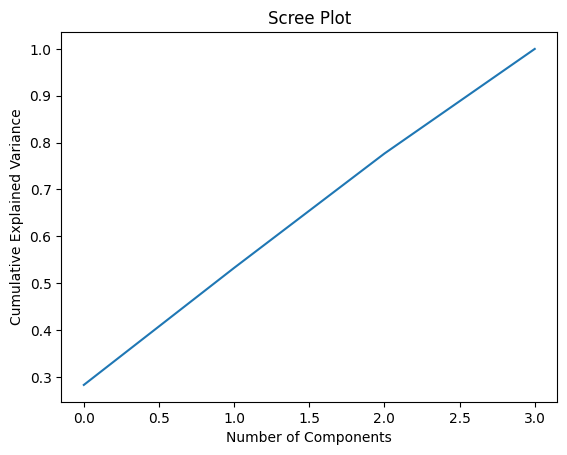

In [ ]:
# Analyzing PCA results
# Plot the explained variance ratio
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.show()

This shows that component-1 explain 33.33% variance, component-2 explains 66.67% variance and component-3 explains 100% variance.

Therefore, we should all the three components.

In [ ]:
# Calculating three principle componenets
pca = PCA(n_components=3)
principal_components = pca.fit_transform(scaled_data)

In [ ]:
# Interpretation
# Get loadings matrix (rows = original variables, columns = PCs)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df[multcol_cols].columns
)

print(loadings)

                    PC1       PC2       PC3
CreditScore   -0.106784  0.973392  0.202549
Gender        -0.426922 -0.218840  0.838073
transf_Age     0.665027  0.053653  0.125177
NumOfProducts -0.603386  0.041706 -0.490854


In [ ]:
# Using PCA output
# Convert principal components to a DataFrame
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2', 'PC3'])

# Drop original multicollinear columns from the main dataset
df_clean = df1.drop(columns=multcol_cols)

# Merge PCA components with the cleaned dataset
final_df = pd.concat([df_clean, pca_df], axis=1)

In [ ]:
final_df

,Geography,Tenure,HasCrCard,IsActiveMember,EstimatedSalary,PC1,PC2,PC3
0,1,1095,1,0,181449.97,-1.222383,-0.045501,0.301590
1,1,365,1,1,49503.50,-1.167725,-0.543733,0.197915
2,1,3650,1,0,184866.69,-0.660072,0.122461,0.435229
3,1,730,1,1,84560.88,0.087482,-1.171597,0.995843
4,3,1825,1,1,15068.83,-1.286373,0.537796,0.422965
...,...,...,...,...,...,...,...,...
164997,3,730,1,1,131834.75,0.742732,0.307484,-0.494085
164998,1,1095,0,0,131834.45,-0.105960,1.399566,1.545925
164999,1,1825,1,1,127429.56,-0.175335,-1.388954,0.901900
165000,3,2555,0,1,71173.03,0.597927,-1.089530,-0.835436


In [ ]:
# Saved PCs to CSv file
final_df.to_csv("../data/preprocessed/df_with_pc.csv", index=False) # Change file path as per your directory structure

In [ ]:
# VIFs after PCs
#from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = final_df.columns
vif_data['VIF'] = [variance_inflation_factor(final_df.values, i) for i in range(final_df.shape[1])]

print(vif_data)


           Feature       VIF
0        Geography  3.858086
1           Tenure  3.442307
2        HasCrCard  3.328513
3   IsActiveMember  1.866942
4  EstimatedSalary  4.286402
5              PC1  1.003796
6              PC2  1.000145
7              PC3  1.000180


## 3. Logistic Regression

In [ ]:
final_df = pd.read_csv("../data/preprocessed/df_with_pc.csv")   #Change file path as per your directory structure

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Splitting for training and testing
X = final_df.drop("Churn", axis=1)
y = final_df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Starndardizing
cols_to_stand = ["Geography", "Tenure",	"HasCrCard",	"IsActiveMember",	"EstimatedSalary"]
pc_columns = ["PC1", "PC2", "PC3"]
# Separate the columns to be standardized and the principal component columns
X_train_to_standardize = X_train[cols_to_stand]
X_train_pc = X_train[pc_columns]

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_train_to_standardize)
X_standardized = pd.DataFrame(X_standardized, columns=cols_to_stand, index=X_train.index) # Keep index

# Concatenate the standardized columns with the principal component columns
X_train_stand = pd.concat([X_standardized, X_train_pc], axis=1)

In [ ]:
# Separate the columns to be standardized and the principal component columns
X_test_to_standardize = X_test[cols_to_stand]
X_test_pc = X_test[pc_columns]

scaler = StandardScaler()
X_test_standardized = scaler.transform(X_test_to_standardize)
X_test_standardized = pd.DataFrame(X_test_standardized, columns=cols_to_stand, index=X_test.index) # Keep index

# Concatenate the standardized columns with the principal component columns
X_test_stand = pd.concat([X_test_standardized, X_test_pc], axis=1)

In [ ]:
# Scaled (standardized) training set
X_train_stand

,Geography,Tenure,HasCrCard,IsActiveMember,EstimatedSalary,PC1,PC2,PC3
70550,-0.792728,-0.366050,0.570175,-0.998797,0.810989,-0.673029,1.461817,-1.199933
67272,-0.792728,-1.433689,0.570175,-0.998797,-0.703040,0.270765,-1.254887,1.008105
5449,-0.792728,-0.010171,-1.753847,-0.998797,-2.229858,1.196868,0.074412,-0.469755
6718,-0.792728,-1.789568,-1.753847,-0.998797,-0.791473,-1.966632,-0.179102,0.144823
49118,0.433496,-1.077809,0.570175,1.001204,-1.067036,-0.534317,-1.706330,0.041961
...,...,...,...,...,...,...,...,...
119879,-0.792728,0.345708,-1.753847,-0.998797,-1.200198,0.008688,0.354492,1.328460
103694,-0.792728,-1.077809,0.570175,-0.998797,-0.691188,1.770931,-0.651627,-0.536814
131932,0.433496,1.769226,0.570175,-0.998797,-0.594636,0.074010,-0.240957,1.204556
146867,-0.792728,1.413347,0.570175,1.001204,0.602339,-0.810906,0.110292,0.406837


In [ ]:
# Scaled (standardized) testing set
X_test_stand

,Geography,Tenure,HasCrCard,IsActiveMember,EstimatedSalary,PC1,PC2,PC3
102571,-0.797884,-0.000614,0.573890,1.012338,-1.446118,2.121978,0.390131,1.695666
118308,-0.797884,0.356902,0.573890,-0.987812,0.657127,-2.037338,-0.711968,0.011992
156915,-0.797884,-0.715645,0.573890,-0.987812,-0.652481,-2.010172,0.338103,-0.472288
70022,1.643988,-0.358130,-1.742494,1.012338,-2.209339,-1.401001,0.712442,0.443083
57411,0.423052,0.356902,-1.742494,1.012338,-0.026315,1.308152,-0.235359,-0.521078
...,...,...,...,...,...,...,...,...
139780,-0.797884,-0.000614,0.573890,1.012338,0.255568,-0.140923,-0.775535,-1.616779
113382,1.643988,0.356902,0.573890,1.012338,0.041530,0.594663,-1.339092,1.044056
30123,1.643988,-0.000614,0.573890,-0.987812,-1.153306,1.314323,1.052395,-0.228059
22776,0.423052,0.356902,0.573890,1.012338,-1.705357,0.887509,-0.966382,0.451348


In [ ]:
# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_stand, y_train)

LogisticRegression()

In [ ]:
# Predict on test data
y_pred = log_reg.predict(X_test_stand)

# Evaluate accuracy and other metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.829841821377346
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90     39099
           1       0.69      0.35      0.46     10402

    accuracy                           0.83     49501
   macro avg       0.77      0.65      0.68     49501
weighted avg       0.81      0.83      0.81     49501



In [ ]:
coefficients = log_reg.coef_[0]
coefficients

array([ 0.11458198, -0.04832053, -0.06317833, -0.59076422,  0.05282464,
        1.0554093 ,  0.03790287,  0.06973769])

### Applying SMOTE for resampling

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_stand, y_train)
print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts()}")

Before SMOTE: Churn
0    90988
1    24513
Name: count, dtype: int64
After SMOTE: Churn
0    90988
1    90988
Name: count, dtype: int64


In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [ ]:
# Predict on test data
y_pred = log_reg.predict(X_test_stand)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7303286802286822
Confusion Matrix:
 [[28471 10628]
 [ 2721  7681]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81     39099
           1       0.42      0.74      0.54     10402

    accuracy                           0.73     49501
   macro avg       0.67      0.73      0.67     49501
weighted avg       0.81      0.73      0.75     49501



In [ ]:
coefficients = log_reg.coef_[0]
intercept = log_reg.intercept_
print("The coefficients are:", coefficients)
print("The intercept is:", intercept)

The coefficients are: [ 0.12980331 -0.05003956 -0.07797838 -0.569709    0.04649561  0.98458983
  0.04341899  0.0050123 ]
The intercept is: [-0.39781649]


## 4. Feature importance using XGBoost (Extreme Gradient Boosting

In [ ]:
# require libraies
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Define features and target
X = final_df.drop("Churn", axis=1)
y = final_df['Churn']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Create and train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    nthread=4,
    scale_pos_weight=1,
    seed=42
)

# Handle class imbalance if needed
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_model.scale_pos_weight = scale_pos_weight

# Train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, nthread=4,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions
y_pred = xgb_model.predict(X_test)

# Print metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.7948
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     39099
           1       0.51      0.79      0.62     10402

    accuracy                           0.79     49501
   macro avg       0.72      0.79      0.74     49501
weighted avg       0.84      0.79      0.81     49501



           Feature  Importance
3   IsActiveMember    0.425846
5              PC1    0.247357
7              PC3    0.136500
0        Geography    0.113615
6              PC2    0.029649
2        HasCrCard    0.024880
4  EstimatedSalary    0.011382
1           Tenure    0.010772


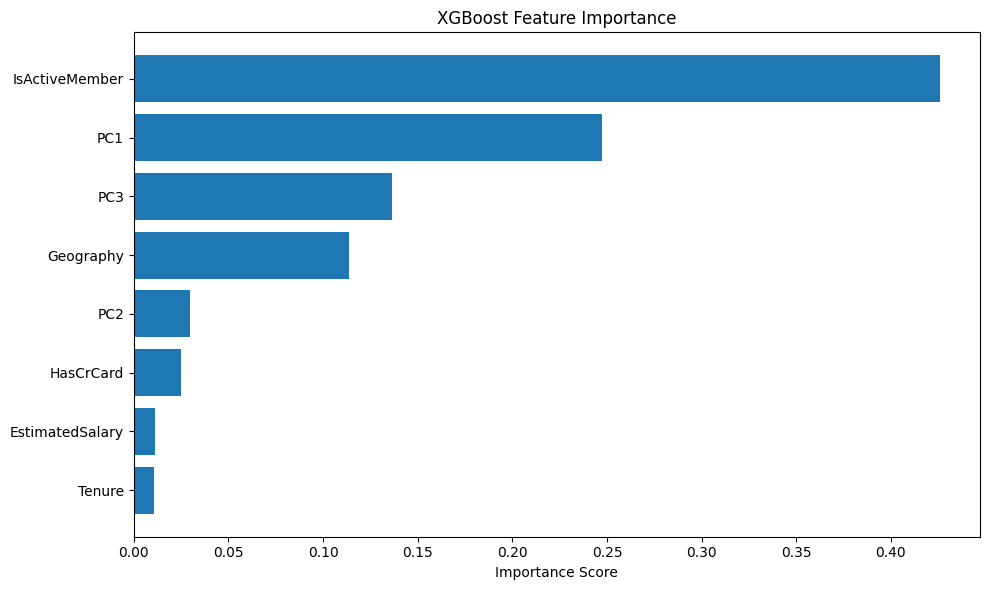

In [ ]:
# Get feature importance
importance = xgb_model.feature_importances_
feature_names = X.columns

# Create DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()  # Display most important at the top
plt.tight_layout()
plt.show()

## 5. Clustering using K-means

In [ ]:
final_df.head()

,Geography,Tenure,HasCrCard,IsActiveMember,EstimatedSalary,PC1,PC2,PC3,Churn
0,1,1095,1,0,181449.97,-1.222383,-0.045501,0.301590,0
1,1,365,1,1,49503.50,-1.167725,-0.543733,0.197915,0
2,1,3650,1,0,184866.69,-0.660072,0.122461,0.435229,0
3,1,730,1,1,84560.88,0.087482,-1.171597,0.995843,0
4,3,1825,1,1,15068.83,-1.286373,0.537796,0.422965,0


In [ ]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler

# Splitting for training and testing
X = final_df.drop(columns=["Churn"], axis=1)
y = final_df["Churn"]

# Starndardizing
cols_to_stand = ["Geography", "Tenure",	"HasCrCard",	"IsActiveMember",	"EstimatedSalary"]
pc_columns = ["PC1", "PC2", "PC3"]
# Separate the columns to be standardized and the principal component columns
X_to_standardize = X[cols_to_stand]
X_pc = X[pc_columns]

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_to_standardize)
X_standardized = pd.DataFrame(X_standardized, columns=cols_to_stand, index=X.index) # Keep index

# Concatenate the standardized columns with the principal component columns
X_stand = pd.concat([X_standardized, X_pc], axis=1)

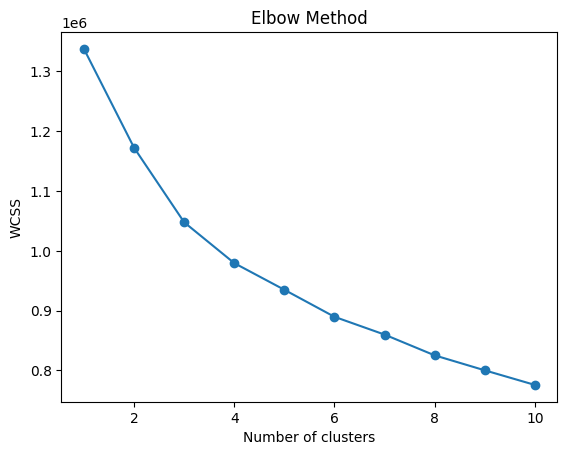

In [ ]:
# Determining optimal cluster using Elbow method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS (Within-Cluster Sum of Squares) for different k values
wcss = []
range_values = range(1, 11) # Looking for optimal k from 1 to 10
for i in range_values:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_stand)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range_values, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Applying K-means clustering
# Choose the optimal number of clusters
n_clusters = 3 # Or whatever number you determined from Elbow or Silhouette

# Apply K-Means
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_stand)

# Add cluster assignments to the original dataframe
final_df['Cluster'] = y_kmeans

In [ ]:
# Analyze clusters
# Analyze cluster characteristics
cluster_summary = final_df.groupby('Cluster').mean()
print(cluster_summary)

         Geography       Tenure  HasCrCard  IsActiveMember  EstimatedSalary  \
Cluster                                                                       
0         1.672471  1822.869387        0.0         0.51617    112182.911068   
1         1.636838  1829.982345        1.0         1.00000    112259.712881   
2         1.644615  1841.093943        1.0         0.00000    113133.645696   

              PC1       PC2       PC3     Churn  
Cluster                                          
0        0.021417  0.007789 -0.001612  0.227408  
1       -0.059322  0.005559  0.010243  0.116689  
2        0.043638 -0.010379 -0.008875  0.293279  


In [ ]:
# Saved as feature in CSV file
final_df.to_csv("../data/preprocessed/df_with_pc.csv", index=False) # Change file path as per your directory structure